In [13]:
import geopandas as gpd
import pandas as pd
from os import listdir
import seaborn as sns
from shapely.geometry import Polygon
import geoparquet_io as gpio
import numpy as np

In [14]:
size = 200

In [15]:
liste_files = listdir('carreaux_200/')

In [16]:
liste_dep = pd.read_json('dep_dispo_2026_01_07.json')
liste_dep.head(3)

,codgeo,year,link
168,95,2021,https://data.geopf.fr/telechargement/download/...
165,94,2021,https://data.geopf.fr/telechargement/download/...
162,93,2021,https://data.geopf.fr/telechargement/download/...


In [17]:
temp = []
liste_idf = ['75', '77', '78', '91', '92', '93', '94', '95']
liste_idf = ['carreaux_'+str(dep)+'.csv'  for dep in liste_idf]
for file in liste_files:
    df_temp = pd.read_csv('carreaux_200/'+ file)
    df_temp['annee'] = liste_dep.loc[liste_dep.codgeo==file[9:11], 'year'].values[0]
    df_temp['codgeo'] = file[9:11]
    temp.append(df_temp)

In [18]:
temp_annee = pd.concat(temp).groupby(['x', 'y', 'annee'], as_index=False).surface.sum()
temp_annee['surface_annee'] = temp_annee.annee * temp_annee.surface
temp_annee = temp_annee.groupby(['x', 'y'], as_index=False)[['surface', 'surface_annee']].sum()
temp_annee['annee'] = temp_annee.surface_annee / temp_annee.surface
temp_annee['surface'] = temp_annee.surface / 1000**2
carreaux = temp_annee[['x', 'y', 'annee', 'surface']]

In [19]:
temp_cs = pd.concat(temp).groupby(['x', 'y', 'code_cs'], as_index=False).surface.sum()
temp_cs.surface = temp_cs.surface / 1000**2 
carreaux_cs = temp_cs.pivot(values='surface', index=['x', 'y'], columns='code_cs').reset_index().fillna(0)

In [20]:
temp_us = pd.concat(temp).groupby(['x', 'y', 'code_us'], as_index=False).surface.sum()
temp_us.surface = temp_us.surface / 1000**2 
carreaux_us = temp_us.pivot(values='surface', index=['x', 'y'], columns='code_us').reset_index().fillna(0)

In [21]:
temp_cs_us = pd.concat(temp).groupby(['x', 'y', 'code_cs', 'code_us'], as_index=False).surface.sum()
temp_cs_us.surface = temp_cs_us.surface / 1000**2 
carreaux_cs_us = temp_cs_us.pivot(values='surface', index=['x', 'y'], columns=['code_cs', 'code_us']).reset_index().fillna(0)

In [22]:
columns =  ['_'.join(c)   for c in  carreaux_cs_us.columns]
columns[0] = 'x'
columns[1] = 'y'
carreaux_cs_us.columns = columns

In [23]:
carreaux = pd.merge(carreaux, carreaux_cs, left_on=['x', 'y'], right_on=['x', 'y'])  
carreaux = pd.merge(carreaux, carreaux_us, left_on=['x', 'y'], right_on=['x', 'y'])
carreaux = pd.merge(carreaux, carreaux_cs_us, left_on=['x', 'y'], right_on=['x', 'y'])

In [24]:
geometry = [Polygon([(x,y),(x+size,y),(x+size,y+size),(x,y+size),(x,y) ]) for x,y in zip(carreaux.y, carreaux.x)]

In [ ]:
carreaux = gpd.GeoDataFrame(carreaux, geometry=geometry, crs=3035)

In [ ]:
carreaux['id_carreau_1km'] =  "FR_CRS3035RES" + str(size) + "mN" + carreaux.x.astype(str) + "E" + carreaux.y.astype(str) 

In [ ]:
carreaux.columns = [col.replace('.', '_') for col in carreaux.columns]

In [ ]:
carreaux['CS1_1'] = carreaux['CS1_1_1_1'] + carreaux['CS1_1_1_2'] + carreaux['CS1_1_2_1'] + carreaux['CS1_1_2_2']
carreaux['CS1_2'] = carreaux['CS1_2_1'] + carreaux['CS1_2_2'] + carreaux['CS1_2_3']
carreaux['CS2_1'] = carreaux['CS2_1_1_1'] + carreaux['CS2_1_1_2'] + carreaux['CS2_1_1_3'] + carreaux['CS2_1_2'] + carreaux['CS2_1_3']
carreaux['CS2_2'] = carreaux['CS2_2_1'] #+ carreaux['CS2_2_2']
carreaux['CS1'] = carreaux['CS1_1'] + carreaux['CS1_2']
carreaux['CS2'] = carreaux['CS2_1'] + carreaux['CS2_2']

In [ ]:
carreaux.drop(columns=['x', 'y'], inplace=True)

In [30]:
carreaux = carreaux[['id_carreau_1km', 'annee',  'surface', 'CS1_1', 'CS1_2', 'CS2_1', 'CS2_2', 'CS1', 'CS2',
                     'CS1_1_1_1',  'CS1_1_1_2',  'CS1_1_2_1',
                     'CS1_1_2_2', 'CS1_2_1', 'CS1_2_2', 'CS1_2_3', 'CS2_1_1_1', 'CS2_1_1_2', 'CS2_1_1_3',
                     'CS2_1_2', 'CS2_1_3', 'CS2_2_1', 'US1_1', 'US1_2', 'US1_3', 'US1_4', 'US1_5', 'US2', 
                     'US235', 'US3', 'US4_1_1', 'US4_1_2', 'US4_1_3', 'US4_1_4', 'US4_1_5', 'US4_2', 'US4_3',
                     'US5', 'US6_1', 'US6_2', 'US6_3', 'US6_6', 'CS1_2_1_US6_3', 'CS1_2_2_US6_3', 'CS1_1_1_1_US3', 
                     'CS1_1_1_2_US3', 'CS2_1_2_US6_3', 'CS2_2_1_US3', 'CS2_2_1_US6_3', 'CS1_2_2_US4_1_4', 'CS1_1_1_1_US6_1',
                     'CS2_1_1_3_US1_2', 'CS1_1_1_1_US5', 'CS2_1_1_1_US1_2', 'CS2_1_1_1_US5', 'CS2_2_1_US5', 'CS1_1_1_2_US4_1_1',
                     'CS1_1_2_1_US5', 'CS2_1_1_3_US3', 'CS1_1_2_1_US3', 'CS1_1_2_1_US4_1_1', 'CS2_1_1_1_US3', 'CS1_1_2_1_US4_1_4',
                     'CS2_2_1_US4_1_1', 'CS2_1_1_2_US1_2', 'CS2_1_2_US1_1', 'CS1_1_1_1_US1_1', 'CS2_1_2_US3', 'CS2_2_1_US1_1',
                     'CS1_1_1_2_US5', 'CS2_1_1_1_US1_1', 'CS2_1_1_3_US5', 'CS2_1_2_US5', 'CS1_1_2_1_US4_3', 'CS1_1_2_1_US6_1',
                     'CS1_2_2_US3', 'CS2_1_1_1_US6_3', 'CS2_1_1_2_US5', 'CS1_1_1_2_US1_1', 'CS1_1_1_1_US4_3', 'CS2_2_1_US2',
                     'CS2_2_1_US4_3', 'CS2_1_1_3_US6_3', 'CS2_2_1_US6_1', 'CS1_1_2_1_US1_1', 'CS2_1_3_US1_1', 'CS1_1_1_1_US2',
                     'CS1_1_1_1_US6_2', 'CS1_1_2_1_US2', 'CS2_1_2_US2', 'CS1_1_2_1_US235', 'CS1_1_1_2_US4_3', 'CS2_1_1_2_US3',
                     'CS2_1_2_US235', 'CS2_1_1_2_US6_3', 'CS2_1_2_US1_2', 'CS1_1_2_1_US1_3', 'CS2_1_2_US1_3', 'CS2_1_1_1_US4_1_1',
                     'CS1_1_1_1_US1_3', 'CS2_1_1_1_US1_3', 'CS1_1_1_2_US4_1_3', 'CS2_2_1_US4_1_3', 'CS1_1_1_1_US4_1_3', 'CS1_1_1_2_US2',
                     'CS1_1_2_1_US4_1_3', 'CS2_1_2_US4_1_3', 'CS2_1_2_US4_3', 'CS2_1_2_US4_1_1', 'CS1_1_1_1_US235', 'CS1_1_1_2_US1_3',
                     'CS1_2_2_US1_3', 'CS2_2_1_US1_3', 'CS1_1_1_2_US235', 'CS1_2_2_US4_3', 'CS2_1_1_1_US235', 'CS2_2_1_US235',
                     'CS1_1_1_1_US4_2', 'CS1_1_1_2_US4_2', 'CS2_1_1_2_US4_1_1', 'CS2_1_1_1_US2', 'CS1_1_1_2_US4_1_4', 'CS1_1_1_1_US4_1_4',
                     'CS1_1_2_2_US2', 'CS1_1_2_1_US6_2', 'CS1_1_1_2_US4_1_2', 'CS1_1_1_1_US4_1_2', 'CS1_1_2_1_US4_1_2', 'CS2_2_1_US4_1_2',
                     'CS2_1_2_US4_1_2', 'CS2_1_2_US6_1', 'CS2_1_1_3_US4_1_1', 'CS1_1_1_2_US6_1', 'CS1_1_1_1_US4_1_1', 'CS1_2_2_US1_1',
                     'CS2_1_1_3_US2', 'CS1_1_2_1_US4_2', 'CS2_1_1_2_US2', 'CS1_1_1_1_US1_4', 'CS1_1_1_2_US1_4', 'CS2_2_1_US1_4',
                     'CS1_2_2_US5', 'CS1_2_2_US2', 'CS2_1_1_2_US235', 'CS2_1_3_US5', 'CS1_1_1_2_US6_2', 'CS2_2_1_US4_2',
                     'CS1_1_1_1_US4_1_5', 'CS1_1_2_1_US4_1_5', 'CS1_2_3_US6_3', 'CS1_1_2_1_US6_3', 'CS1_1_2_1_US1_4', 'CS1_2_2_US1_4',
                     'CS2_1_2_US6_2', 'CS2_1_1_3_US235', 'CS2_1_3_US3', 'CS1_1_2_1_US1_2', 'CS2_1_1_3_US1_3', 'CS2_1_1_2_US1_3',
                     'CS2_1_1_1_US6_2', 'CS2_2_1_US4_1_5', 'CS1_2_2_US235', 'CS1_1_2_2_US4_3', 'CS1_1_2_2_US235', 'CS2_2_1_US6_6',
                     'CS1_1_2_2_US3', 'CS1_1_2_1_US6_6', 'CS2_1_2_US4_2', 'CS1_2_2_US4_1_1', 'CS1_1_1_2_US1_2', 'CS2_1_3_US235',
                     'CS1_1_2_2_US5', 'CS1_1_1_1_US6_6', 'CS1_1_1_2_US6_6', 'CS2_1_1_1_US6_6', 'CS2_1_1_1_US1_5', 'CS2_1_1_1_US4_3',
                     'CS2_1_2_US1_5', 'CS1_1_2_2_US6_2', 'CS2_1_1_1_US4_1_2', 'CS2_1_1_2_US4_3', 'CS2_2_1_US4_1_4', 'CS2_1_1_1_US4_1_3',
                     'CS2_1_1_3_US4_1_2', 'CS2_1_1_2_US4_1_2', 'CS2_1_3_US2', 'CS2_2_1_US6_2',  'CS2_1_1_3_US6_2', 'CS2_1_1_2_US4_1_3',
                     'CS1_1_1_2_US4_1_5', 'CS1_1_1_2_US6_3',  'geometry']]

In [31]:
carreaux['max_cs'] = carreaux[['CS1_1_1_1',  'CS1_1_1_2',  'CS1_1_2_1',
                     'CS1_1_2_2', 'CS1_2_1', 'CS1_2_2', 'CS1_2_3', 'CS2_1_1_1', 'CS2_1_1_2', 'CS2_1_1_3',
                     'CS2_1_2', 'CS2_1_3', 'CS2_2_1']].idxmax(axis=1)

In [5]:
carreaux['max_cs'][:1000].unique()

array(['CS2_1_2', 'CS2_1_1_1', 'CS2_2_1', 'CS2_1_1_3'], dtype=object)

In [39]:
carreaux.to_parquet('ocsge_2022_carreaux_200m.parquet')
gpio.read('ocsge_2022_carreaux_200m.parquet') \
    .add_bbox() \
    .sort_hilbert() \
    .write('ocsge_2022_carreaux_200m.parquet', compression='ZSTD')

PosixPath('ocsge_2022_carreaux_200m.parquet')

In [33]:
subcarreaux =  carreaux[['id_carreau_1km', 'annee',  'surface', 'CS1_1', 'CS1_2', 'CS2_1', 'CS2_2', 'CS1', 'CS2',
                     'CS1_1_1_1',  'CS1_1_1_2',  'CS1_1_2_1',
                     'CS1_1_2_2', 'CS1_2_1', 'CS1_2_2', 'CS1_2_3', 'CS2_1_1_1', 'CS2_1_1_2', 'CS2_1_1_3',
                     'CS2_1_2', 'CS2_1_3', 'CS2_2_1', 'geometry']]

In [8]:
subcarreaux.to_parquet('ocsge_2022_carreaux_200m_cs.parquet')
gpio.read('ocsge_2022_carreaux_200m.parquet') \
    .add_bbox() \
    .sort_hilbert() \
    .write('ocsge_2022_carreaux_200m_cs.parquet', compression='ZSTD')

NameError: name 'subcarreaux' is not defined

In [34]:
carreaux.columns

Index(['id_carreau_1km', 'annee', 'surface', 'CS1_1', 'CS1_2', 'CS2_1',
       'CS2_2', 'CS1', 'CS2', 'CS1_1_1_1',
       ...
       'CS2_1_1_3_US4_1_2', 'CS2_1_1_2_US4_1_2', 'CS2_1_3_US2',
       'CS2_2_1_US6_2', 'CS2_1_1_3_US6_2', 'CS2_1_1_2_US4_1_3',
       'CS1_1_1_2_US4_1_5', 'CS1_1_1_2_US6_3', 'geometry', 'max_cs'],
      dtype='object', length=193)

KeyboardInterrupt: 

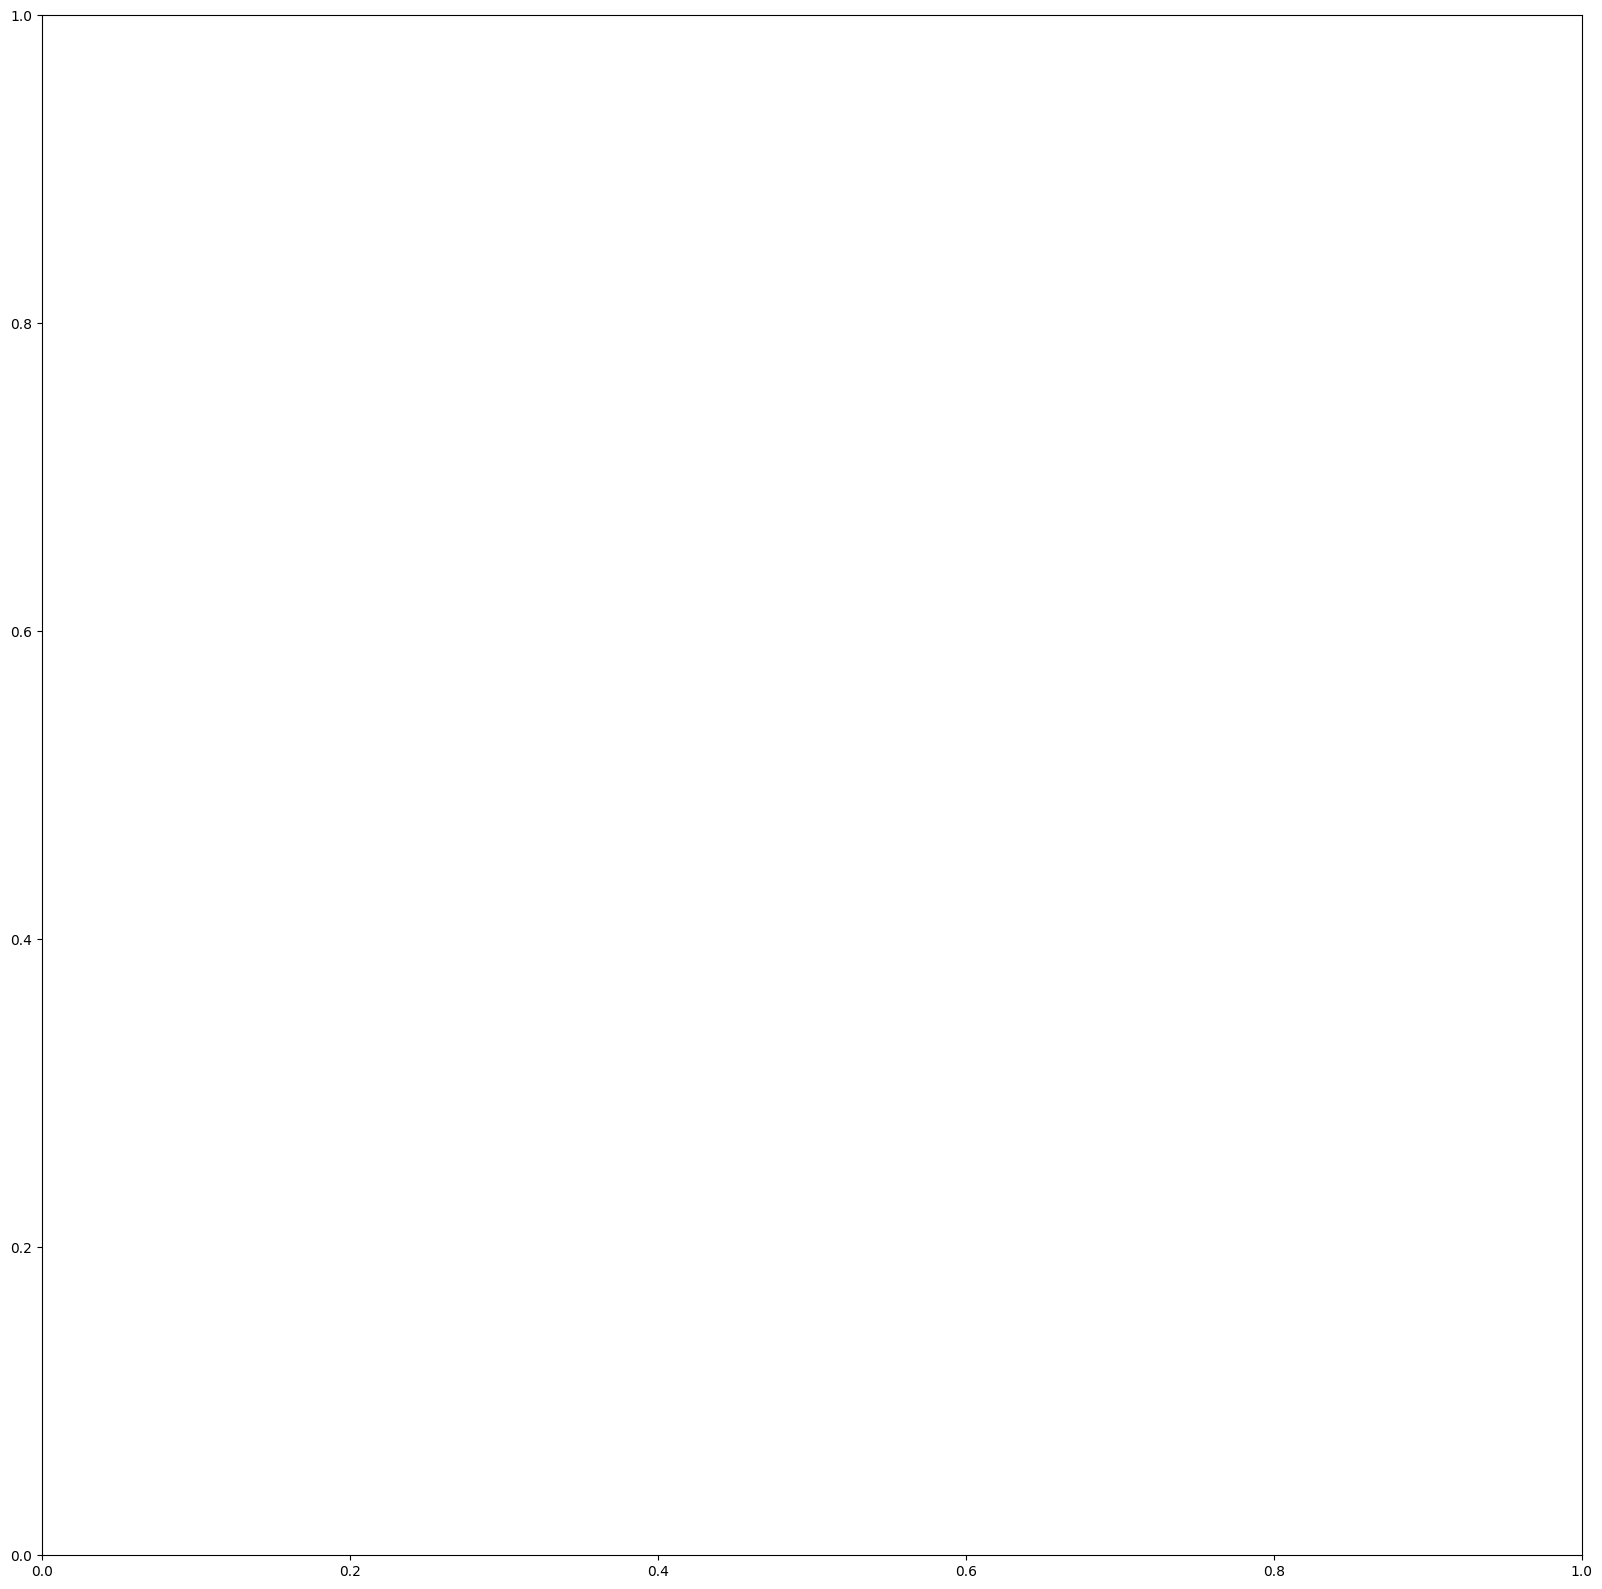

In [41]:
carreaux.plot('max_cs',categorical=True, figsize=(20,20))

In [22]:
carreaux.surface.sum()

np.float64(549146.6715599641)

In [30]:
carreaux.CS1_1.sum()

np.float64(25682.087556733088)

In [31]:
carreaux.CS1.sum()

np.float64(37758.724124633525)

In [32]:
carreaux.CS2.sum()

np.float64(511387.94743533054)

## Département

In [6]:
temp_annee = pd.concat(temp).groupby(['codgeo', 'annee'], as_index=False).surface.sum()
temp_annee['surface_annee'] = temp_annee.annee * temp_annee.surface
temp_annee = temp_annee.groupby(['codgeo'], as_index=False)[['surface', 'surface_annee']].sum()
temp_annee['annee'] = temp_annee.surface_annee / temp_annee.surface
temp_annee['surface'] = temp_annee.surface / size**2
departement = temp_annee[['codgeo', 'annee', 'surface']]

In [7]:
temp_cs = pd.concat(temp).groupby(['codgeo', 'code_cs'], as_index=False).surface.sum()
temp_cs.surface = temp_cs.surface / size**2 
departement_cs = temp_cs.pivot(values='surface', index=['codgeo'], columns='code_cs').reset_index().fillna(0)

In [8]:
temp_us = pd.concat(temp).groupby(['codgeo', 'code_us'], as_index=False).surface.sum()
temp_us.surface = temp_us.surface / size**2 
departement_us = temp_us.pivot(values='surface', index=['codgeo'], columns='code_us').reset_index().fillna(0)

In [9]:
temp_cs_us = pd.concat(temp).groupby(['codgeo', 'code_cs', 'code_us'], as_index=False).surface.sum()
temp_cs_us.surface = temp_cs_us.surface / size**2 
departement_cs_us = temp_cs_us.pivot(values='surface', index=['codgeo'], columns=['code_cs', 'code_us']).reset_index().fillna(0)

columns =  ['_'.join(c)   for c in  departement_cs_us.columns]
columns[0] = 'codgeo'
departement_cs_us.columns = columns

In [10]:
departement = pd.merge(departement, departement_cs, left_on=['codgeo'], right_on=['codgeo'])  
departement = pd.merge(departement, departement_us, left_on=['codgeo'], right_on=['codgeo'])
departement = pd.merge(departement, departement_cs_us, left_on=['codgeo'], right_on=['codgeo'])

In [11]:
departement.columns = [col.replace('.', '_') for col in departement.columns]

In [12]:
departement['CS1_1'] = departement['CS1_1_1_1'] + departement['CS1_1_1_2'] + departement['CS1_1_2_1'] + departement['CS1_1_2_2']
departement['CS1_2'] = departement['CS1_2_1'] + departement['CS1_2_2'] + departement['CS1_2_3']
departement['CS2_1'] = departement['CS2_1_1_1'] + departement['CS2_1_1_2'] + departement['CS2_1_1_3'] + departement['CS2_1_2'] + departement['CS2_1_3']
departement['CS2_2'] = departement['CS2_2_1'] #+ carreaux['CS2_2_2']
departement['CS1'] = departement['CS1_1'] + departement['CS1_2']
departement['CS2'] = departement['CS2_1'] + departement['CS2_2']

In [13]:
departement = departement[['codgeo', 'annee',  'surface', 'CS1_1', 'CS1_2', 'CS2_1', 'CS2_2', 'CS1', 'CS2',
                     'CS1_1_1_1',  'CS1_1_1_2',  'CS1_1_2_1',
                     'CS1_1_2_2', 'CS1_2_1', 'CS1_2_2', 'CS1_2_3', 'CS2_1_1_1', 'CS2_1_1_2', 'CS2_1_1_3',
                     'CS2_1_2', 'CS2_1_3', 'CS2_2_1', 'US1_1', 'US1_2', 'US1_3', 'US1_4', 'US1_5', 'US2', 
                     'US235', 'US3', 'US4_1_1', 'US4_1_2', 'US4_1_3', 'US4_1_4', 'US4_1_5', 'US4_2', 'US4_3',
                     'US5', 'US6_1', 'US6_2', 'US6_3', 'US6_6', 'CS1_2_1_US6_3', 'CS1_2_2_US6_3', 'CS1_1_1_1_US3', 
                     'CS1_1_1_2_US3', 'CS2_1_2_US6_3', 'CS2_2_1_US3', 'CS2_2_1_US6_3', 'CS1_2_2_US4_1_4', 'CS1_1_1_1_US6_1',
                     'CS2_1_1_3_US1_2', 'CS1_1_1_1_US5', 'CS2_1_1_1_US1_2', 'CS2_1_1_1_US5', 'CS2_2_1_US5', 'CS1_1_1_2_US4_1_1',
                     'CS1_1_2_1_US5', 'CS2_1_1_3_US3', 'CS1_1_2_1_US3', 'CS1_1_2_1_US4_1_1', 'CS2_1_1_1_US3', 'CS1_1_2_1_US4_1_4',
                     'CS2_2_1_US4_1_1', 'CS2_1_1_2_US1_2', 'CS2_1_2_US1_1', 'CS1_1_1_1_US1_1', 'CS2_1_2_US3', 'CS2_2_1_US1_1',
                     'CS1_1_1_2_US5', 'CS2_1_1_1_US1_1', 'CS2_1_1_3_US5', 'CS2_1_2_US5', 'CS1_1_2_1_US4_3', 'CS1_1_2_1_US6_1',
                     'CS1_2_2_US3', 'CS2_1_1_1_US6_3', 'CS2_1_1_2_US5', 'CS1_1_1_2_US1_1', 'CS1_1_1_1_US4_3', 'CS2_2_1_US2',
                     'CS2_2_1_US4_3', 'CS2_1_1_3_US6_3', 'CS2_2_1_US6_1', 'CS1_1_2_1_US1_1', 'CS2_1_3_US1_1', 'CS1_1_1_1_US2',
                     'CS1_1_1_1_US6_2', 'CS1_1_2_1_US2', 'CS2_1_2_US2', 'CS1_1_2_1_US235', 'CS1_1_1_2_US4_3', 'CS2_1_1_2_US3',
                     'CS2_1_2_US235', 'CS2_1_1_2_US6_3', 'CS2_1_2_US1_2', 'CS1_1_2_1_US1_3', 'CS2_1_2_US1_3', 'CS2_1_1_1_US4_1_1',
                     'CS1_1_1_1_US1_3', 'CS2_1_1_1_US1_3', 'CS1_1_1_2_US4_1_3', 'CS2_2_1_US4_1_3', 'CS1_1_1_1_US4_1_3', 'CS1_1_1_2_US2',
                     'CS1_1_2_1_US4_1_3', 'CS2_1_2_US4_1_3', 'CS2_1_2_US4_3', 'CS2_1_2_US4_1_1', 'CS1_1_1_1_US235', 'CS1_1_1_2_US1_3',
                     'CS1_2_2_US1_3', 'CS2_2_1_US1_3', 'CS1_1_1_2_US235', 'CS1_2_2_US4_3', 'CS2_1_1_1_US235', 'CS2_2_1_US235',
                     'CS1_1_1_1_US4_2', 'CS1_1_1_2_US4_2', 'CS2_1_1_2_US4_1_1', 'CS2_1_1_1_US2', 'CS1_1_1_2_US4_1_4', 'CS1_1_1_1_US4_1_4',
                     'CS1_1_2_2_US2', 'CS1_1_2_1_US6_2', 'CS1_1_1_2_US4_1_2', 'CS1_1_1_1_US4_1_2', 'CS1_1_2_1_US4_1_2', 'CS2_2_1_US4_1_2',
                     'CS2_1_2_US4_1_2', 'CS2_1_2_US6_1', 'CS2_1_1_3_US4_1_1', 'CS1_1_1_2_US6_1', 'CS1_1_1_1_US4_1_1', 'CS1_2_2_US1_1',
                     'CS2_1_1_3_US2', 'CS1_1_2_1_US4_2', 'CS2_1_1_2_US2', 'CS1_1_1_1_US1_4', 'CS1_1_1_2_US1_4', 'CS2_2_1_US1_4',
                     'CS1_2_2_US5', 'CS1_2_2_US2', 'CS2_1_1_2_US235', 'CS2_1_3_US5', 'CS1_1_1_2_US6_2', 'CS2_2_1_US4_2',
                     'CS1_1_1_1_US4_1_5', 'CS1_1_2_1_US4_1_5', 'CS1_2_3_US6_3', 'CS1_1_2_1_US6_3', 'CS1_1_2_1_US1_4', 'CS1_2_2_US1_4',
                     'CS2_1_2_US6_2', 'CS2_1_1_3_US235', 'CS2_1_3_US3', 'CS1_1_2_1_US1_2', 'CS2_1_1_3_US1_3', 'CS2_1_1_2_US1_3',
                     'CS2_1_1_1_US6_2', 'CS2_2_1_US4_1_5', 'CS1_2_2_US235', 'CS1_1_2_2_US4_3', 'CS1_1_2_2_US235', 'CS2_2_1_US6_6',
                     'CS1_1_2_2_US3', 'CS1_1_2_1_US6_6', 'CS2_1_2_US4_2', 'CS1_2_2_US4_1_1', 'CS1_1_1_2_US1_2', 'CS2_1_3_US235',
                     'CS1_1_2_2_US5', 'CS1_1_1_1_US6_6', 'CS1_1_1_2_US6_6', 'CS2_1_1_1_US6_6', 'CS2_1_1_1_US1_5', 'CS2_1_1_1_US4_3',
                     'CS2_1_2_US1_5', 'CS1_1_2_2_US6_2', 'CS2_1_1_1_US4_1_2', 'CS2_1_1_2_US4_3', 'CS2_2_1_US4_1_4', 'CS2_1_1_1_US4_1_3',
                     'CS2_1_1_3_US4_1_2', 'CS2_1_1_2_US4_1_2', 'CS2_1_3_US2', 'CS2_2_1_US6_2',  'CS2_1_1_3_US6_2', 'CS2_1_1_2_US4_1_3',
                     'CS1_1_1_2_US4_1_5', 'CS1_1_1_2_US6_3']]

In [21]:
departement['annee'] = np.round(departement.annee).astype(int)

In [23]:
departement.to_csv('ocsge_2022_departement_1000m.csv', index=False)

In [22]:
departement.head()

,codgeo,annee,surface,CS1_1,CS1_2,CS2_1,CS2_2,CS1,CS2,CS1_1_1_1,...,CS2_2_1_US4_1_4,CS2_1_1_1_US4_1_3,CS2_1_1_3_US4_1_2,CS2_1_1_2_US4_1_2,CS2_1_3_US2,CS2_2_1_US6_2,CS2_1_1_3_US6_2,CS2_1_1_2_US4_1_3,CS1_1_1_2_US4_1_5,CS1_1_1_2_US6_3
0,01,2021,5784.836831,304.321171,138.794618,2327.379190,3014.341853,443.115789,5341.721042,107.631858,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,02,2021,7411.143413,256.527874,56.267880,1767.597177,5330.750482,312.795754,7098.347659,98.143323,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002598
2,03,2022,7379.549457,240.074890,75.908901,1663.995997,5399.569670,315.983790,7063.565666,82.809843,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,04,2021,6995.163289,100.764348,682.210154,4759.972093,1452.216695,782.974501,6212.188788,31.698451,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,05,2022,5689.869883,88.821989,1222.686861,2414.689313,1963.671720,1311.508850,4378.361033,27.972754,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


## Verification

In [165]:
print(carreaux.surface.sum())
print(carreaux.CS1.sum() + carreaux.CS2.sum())

549146.6715599642
549146.6715599641


In [166]:
print(departement.surface.sum())
print(departement.CS1.sum() + departement.CS2.sum())

549146.6715599641
549146.6715599642


In [179]:
np.sum(departement.annee * departement.surface) / departement.surface.sum()

2021.6700623253914